В ./data должны лежать необработанные файлы:
* events_ab.csv
* users_ab.csv
* visits_daily.csv


После выполненияв ./data_processed будут находиться предобработанные файлы (удалены дубликаты, заполнены пропуски и т.д.)
* events_processed.csv
* users_processed.csv
* visits_processed.csv

А в ./eda_plots будут лежать графики:
1) Распределения возрастов (age_distribution.png)
2) Пользователи по городам (city_distribution.png)
3) Пользователи по устройствам (device_distribution.png)
4) Количества всех действий (event_type_distribution.png)
5) Количество пользователей из групп A и B (group_balance.png)
6) Количество пользователей из групп A и B по типу устройства (group_balance_by_device.png)
7) Количество пользователей из групп A и B по типу устройства (другой вид) (group_device_stacked.png)

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [12]:
# конфигурация
DATA_PATH = '/content/data'
PLOTS_PATH = 'eda_plots'

VALID_DEVICES = ['android', 'ios', 'unknown']
VALID_EVENT_TYPES = [
    'login', 'logout', 'screen_view', 'button_click',
    'transaction', 'screen_view_popup'
]

sns.set_theme(style='whitegrid')


Загружаем данные

In [6]:
def load_data():
    users = pd.read_csv(os.path.join(DATA_PATH, 'users_ab.csv'))
    events = pd.read_csv(os.path.join(DATA_PATH, 'events_ab.csv'))
    visits = pd.read_csv(os.path.join(DATA_PATH, 'visits_daily.csv'))
    return users, events, visits


Предобработка users

In [7]:
def process_users_advanced(users: pd.DataFrame) -> pd.DataFrame:
    # очистка users
    users = users.copy()

    users['reg_date'] = pd.to_datetime(users.get('reg_date'), errors='coerce')

    users = users.drop_duplicates()
    users = users.drop_duplicates(subset=['user_id'], keep='first')

    users['age'] = pd.to_numeric(users.get('age'), errors='coerce')
    users = users[(users['age'] >= 14) & (users['age'] <= 100)].copy()

    min_valid_date = pd.Timestamp('2010-01-01')
    users = users[users['reg_date'].notna() & (users['reg_date'] >= min_valid_date)].copy()

    # нормализация device
    users['device'] = users.get('device').fillna('unknown').astype(str).str.lower().str.strip()
    users.loc[users['device'].str.contains('ios', na=False), 'device'] = 'ios'
    users.loc[users['device'].str.contains('android', na=False), 'device'] = 'android'
    users.loc[~users['device'].isin(['ios', 'android']), 'device'] = 'unknown'

    # нормализация city
    users['city'] = users.get('city').fillna('unknown').astype(str).str.strip().str.title()
    city_mapping = {'Нск': 'Новосибирск', 'Мск': 'Москва', 'Спб': 'Санкт-Петербург'}
    users['city'] = users['city'].replace(city_mapping)

    city_counts = users['city'].value_counts(normalize=True)
    small_cities = city_counts[city_counts < 0.01].index
    users.loc[users['city'].isin(small_cities), 'city'] = 'Прочие'

    print("---завершена обработка users_ab.csv -> users_processed.csv---\n")
    return users


Предобработка events

In [8]:
def process_events_logic(events: pd.DataFrame, users: pd.DataFrame) -> pd.DataFrame:
    # очистка events и формирование сессий
    events = events.copy()
    events['event_dt'] = pd.to_datetime(events.get('event_dt'), errors='coerce')

    # оставляем события только для известных пользователей
    df = users[['user_id']].merge(events, on='user_id', how='left')

    # корректность сумм
    if 'amount' in df.columns:
        df = df[df['amount'].isna() | (df['amount'] >= 0)].copy()

    # нормализация event_type
    if 'event_type' in df.columns:
        df['event_type'] = df['event_type'].astype(str).str.strip().str.lower()
        df = df[df['event_type'].isin(VALID_EVENT_TYPES)].copy()
    else:
        print("в events нет колонки 'event_type' — проверь файл")

    # сессии по разрыву >30 минут
    df = df.sort_values(['user_id', 'event_dt'])
    df['prev_time'] = df.groupby('user_id')['event_dt'].shift(1)
    df['time_diff'] = (df['event_dt'] - df['prev_time']).dt.total_seconds() / 60
    df['is_new_session'] = np.where((df['time_diff'] > 30) | (df['time_diff'].isna()), 1, 0)
    df['session_id'] = df.groupby('user_id')['is_new_session'].cumsum().astype(int)

    # удаляем logout как первое событие сессии (как аномалию)
    mask_invalid = (df['event_type'] == 'logout') & (df['is_new_session'] == 1)
    if mask_invalid.any():
        print(f"найдено {mask_invalid.sum()} аномальных logout-событий — удаляю")
        df = df[~mask_invalid].copy()

    print("---завершена обработка events_ab.csv -> events_processed.csv---\n")
    return df


Предобработка visits

In [9]:
def process_visits(visits: pd.DataFrame) -> pd.DataFrame:
    # очистка visits
    visits = visits.copy()
    cols = list(visits.columns)
    if len(cols) >= 2:
        visits = visits.rename(columns={cols[0]: 'дата_события', cols[1]: 'visits'})

    if 'дата_события' in visits.columns:
        visits['дата_события'] = pd.to_datetime(visits['дата_события'], errors='coerce')

    visits = visits.drop_duplicates()

    if 'visits' in visits.columns:
        visits['visits'] = pd.to_numeric(visits['visits'], errors='coerce').fillna(0)
        visits = visits[visits['visits'] >= 0].copy()

    print("---завершена обработка visits_ab.csv -> visits_processed.csv---\n")
    return visits


eda анализ очищенных данных

In [10]:
def perform_eda(users_clean: pd.DataFrame, events_clean: pd.DataFrame, plots_path: str):
    # базовый eda и сохранение графиков
    os.makedirs(plots_path, exist_ok=True)

    # возраст
    plt.figure()
    sns.histplot(data=users_clean, x='age', bins=20, kde=True)
    plt.title('распределение возраста пользователей')
    plt.xlabel('возраст')
    plt.savefig(os.path.join(plots_path, 'age_distribution.png'))
    plt.close()

    # города
    plt.figure(figsize=(10, 6))
    sns.countplot(data=users_clean, y='city',
                  order=users_clean['city'].value_counts().index)
    plt.title('пользователи по городам')
    plt.tight_layout()
    plt.savefig(os.path.join(plots_path, 'city_distribution.png'))
    plt.close()

    # устройства
    plt.figure()
    sns.countplot(data=users_clean, x='device',
                  order=users_clean['device'].value_counts().index)
    plt.title('пользователи по устройствам')
    plt.savefig(os.path.join(plots_path, 'device_distribution.png'))
    plt.close()

    # баланс групп a/b
    plt.figure()
    sns.countplot(data=users_clean, x='group')
    plt.title('баланс групп a/b')
    plt.savefig(os.path.join(plots_path, 'group_balance.png'))
    plt.close()

    # баланс групп a/b: цвет по device
    plt.figure(figsize=(8, 5))
    order = users_clean['group'].value_counts().index  # сохраняем порядок групп
    sns.countplot(data=users_clean, x='group', hue='device', order=order)
    plt.title('баланс групп a/b (цвет = device)')
    plt.legend(title='device', bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.tight_layout()
    plt.savefig(os.path.join(plots_path, 'group_balance_by_device.png'))
    plt.close()

    # баланс групп a/b: цвет по городу
    plt.figure(figsize=(10, 6))
    order = users_clean['city'].value_counts().index
    sns.countplot(data=users_clean, y='city', hue='group', order=order)
    plt.title('баланс групп A/B по городам')
    plt.legend(title='group', bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.tight_layout()
    plt.savefig(os.path.join(plots_path, 'group_balance_by_city.png'))
    plt.close()

    pivot = users_clean.groupby(['group', 'city']).size().unstack(fill_value=0)
    pivot_pct = pivot.div(pivot.sum(axis=1), axis=0)

    ax = pivot_pct.plot(kind='bar', stacked=True, figsize=(10, 6))
    ax.set_title('доля городов внутри групп (stacked, %)')
    ax.set_ylabel('доля')
    ax.legend(title='city', bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.tight_layout()
    plt.savefig(os.path.join(plots_path, 'group_city_stacked.png'))
    plt.close()

    pivot = users_clean.groupby(['group', 'device']).size().unstack(fill_value=0)
    pivot_pct = pivot.div(pivot.sum(axis=1), axis=0)

    ax = pivot_pct.plot(kind='bar', stacked=True, figsize=(8, 5))
    ax.set_title('доля устройств внутри групп (stacked, %)')
    ax.set_ylabel('доля')
    ax.legend(title='device', bbox_to_anchor=(1.05, 1), loc='upper_left' if False else 'upper left')
    plt.tight_layout()
    plt.savefig(os.path.join(plots_path, 'group_device_stacked.png'))
    plt.close()

    # типы событий
    if 'event_type' in events_clean.columns:
        plt.figure(figsize=(10, 7))
        sns.countplot(data=events_clean, y='event_type',
                      order=events_clean['event_type'].value_counts().index)
        plt.title('типы событий')
        plt.tight_layout()
        plt.savefig(os.path.join(plots_path, 'event_type_distribution.png'))
        plt.close()

    print('графики сохранены в папку:', plots_path)


Выполнение всего кода

In [13]:
# запуск обработки
users_raw, events_raw, visits_raw = load_data()

users_clean = process_users_advanced(users_raw)
events_clean = process_events_logic(events_raw, users_clean)
visits_clean = process_visits(visits_raw)

perform_eda(users_clean, events_clean, PLOTS_PATH)

# сохраняем результаты
os.makedirs('./data_processed', exist_ok=True)
users_clean.to_csv('./data_processed/users_processed.csv', index=False)

cols_to_save = ['user_id', 'event_dt', 'event_type', 'session_id']
if 'amount' in events_clean.columns:
    cols_to_save.append('amount')
if 'transaction_type' in events_clean.columns:
    cols_to_save.append('transaction_type')

events_clean[cols_to_save].to_csv('./data_processed/events_processed.csv', index=False)
visits_clean.to_csv('./data_processed/visits_processed.csv', index=False)

print('✅ обработка завершена')


---завершена обработка users_ab.csv -> users_processed.csv---

---завершена обработка events_ab.csv -> events_processed.csv---

---завершена обработка visits_ab.csv -> visits_processed.csv---

графики сохранены в папку: eda_plots
✅ обработка завершена


Результаты

![/content/eda_plots/age_distribution.png](./eda_plots/age_distribution.png "Распределение возраста пользователей")


![./eda_plots/city_distribution.png](./eda_plots/city_distribution.png "Пользователи по городам")


![./eda_plots/device_distribution.png](./eda_plots/device_distribution.png "Пользователи по устройствам")


![./eda_plots/event_type_distribution.png](./eda_plots/event_type_distribution.png "Количество всех типов событий")


![./eda_plots/group_balance.png](./eda_plots/group_balance.png "Количество пользователей из групп A и B")


![./eda_plots/group_balance_by_device.png](./eda_plots/group_balance_by_device.png "Количество пользователей из групп A и B по типу устройства")


![./eda_plots/group_device_stacked.png](./eda_plots/group_device_stacked.png "Количество пользователей из групп A и B по типу устройства (другой вид)")


![./eda_plots/group_balance_by_city.png](./eda_plots/group_balance_by_city.png "Распределение пользователей по A/B группам внутри городов")


![./eda_plots/group_city_stacked.png](./eda_plots/group_city_stacked.png "Распределение пользователей по городам внутри A/B групп")


Микро вывод:
1) Банк используется экономически активным населением в основном в возрасте от 25 до 45 лет
2) Подавляющее большинство пользователей приходится на крупные города (Москва, Санкт-Петербург, Новосибирск, Екатеринбург), все эти города составляют около 80% от общего числа пользователей
3) По типу ОС телефона все пользователи разделились примерно поровну
4) В A/B тесте ОС пользователей также разделены поровну, также равномерно и распределение попо городам

Распределение пользователей по группам A/B скорее всего выполнено корректно


Пункт 5 ТЗ: Проведение расчетов и исследований

In [17]:
# соединяем users и events
df = events_clean.merge(
    users_clean[['user_id', 'group', 'device', 'city']],
    on='user_id',
    how='left'
)

# считаем метрики по сессии
session_stats = (
    df.groupby(['user_id', 'session_id'])
    .agg(events_count=('event_type', 'count'),
        has_transaction=('event_type', lambda x: 'transaction' in set(x)),
        session_start=('event_dt', 'min'),
        session_end=('event_dt', 'max')
        ).reset_index()
)

session_stats['session_duration_min'] = (
    (session_stats['session_end'] - session_stats['session_start']).dt.total_seconds() / 60
)

# метрики по пользователям
user_metrics = (
    session_stats.groupby('user_id')
    .agg(sessions_count=('session_id', 'nunique'),
        events_per_session=('events_count', 'mean'),
        conversion_rate=('has_transaction', 'mean'),
        avg_session_duration_min=('session_duration_min', 'mean')
        ).reset_index()
)

# добавляем категории юзерам
user_metrics = user_metrics.merge(
    users_clean[['user_id', 'group', 'device', 'city']],
    on='user_id'
)

# сводные таблицы
ab_summary = user_metrics.groupby('group').agg({
    'sessions_count': 'mean',
    'events_per_session': 'mean',
    'conversion_rate': 'mean',
    'avg_session_duration_min': 'mean'
})

ab_summary.columns = [
    'Среднее число сессий',
    'Событий на сессию',
    'Конверсия в транзакцию',
    'Средняя длительность сессии (мин)'
]

print("Итоговые метрики A/B-теста")
display(ab_summary)


# сводная таблица: Среднее количество транзакций на пользователя по группам и типам устройств

# число транзакций на пользователя
txn_counts = (
    df[df['event_type'] == 'transaction'].groupby('user_id').size().reset_index(name='txn_count')
)

txn_by_user = txn_counts.merge(
    users_clean[['user_id', 'group', 'device']],
    on='user_id'
)

txn_summary = txn_by_user.groupby(['group', 'device'])['txn_count'].mean().unstack()

print("\nСреднее количество транзакций на пользователя (по группе и устройству)")
display(txn_summary)


# Количество уникальных пользователей, совершивших хотя бы одну транзакцию, по городам и группам
txn_by_city = (
    df[df['event_type'] == 'transaction']
    .groupby(['group', 'city'])['user_id']
    .nunique()
    .unstack(fill_value=0)
)

print("\nУникальные пользователи с ≥1 транзакцией (по группам и городам)")
display(txn_by_city)

# доли в процентах внутри групп
total_users = users_clean.groupby('group')['user_id'].nunique()
txn_by_city_pct = txn_by_city.div(total_users, axis=0).round(4) * 100

print("\nДоля пользователей с ≥1 транзакцией (% от всех пользователей группы)")
display(txn_by_city_pct)


# Распределение событий screen_view
if "screen_view" in df['event_type'].unique():
    sv_counts = df[df['event_type'] == 'screen_view']['event_type'].value_counts()
else:
    sv_counts = df['event_type'].value_counts().loc[lambda x: x.index == "screen_view"]

print("\nКоличество событий screen_view")
display(sv_counts)


# проверка адекватности данных
avg_session_duration = user_metrics['avg_session_duration_min'].mean()

print("\nПроверка адекватности данных")
print(f"Средняя длительность сессии в наших данных: {avg_session_duration:.2f} мин")

market_min = 7
market_max = 8

print(f"Типичный рынок: {market_min}–{market_max} мин (банковские приложения)")

if avg_session_duration > 20:
    print("ПРЕДУПРЕЖДЕНИЕ: Средняя сессия > 20 минут, возможно ошибка в данных")
elif avg_session_duration > market_max:
    print("Сессии длиннее типичных.")
else:
    print("Средняя длительность сессии выглядит реалистично.")


Итоговые метрики A/B-теста


,Среднее число сессий,Событий на сессию,Конверсия в транзакцию,Средняя длительность сессии (мин)
group,,,,
A,5.977026,9.634129,0.773897,5.063997
B,7.852521,9.691613,0.781875,9.727264



Среднее количество транзакций на пользователя (по группе и устройству)


device,android,ios,unknown
group,,,
A,9.297639,8.972269,10.40
B,12.158073,12.099410,10.25



Уникальные пользователи с ≥1 транзакцией (по группам и городам)


...


Доля пользователей с ≥1 транзакцией (% от всех пользователей группы)


city,Unknown,Другой,Екатеринбург,Москва,Новосибирск,Прочие,Санкт-Петербург
group,,,,,,,
A,5.2,15.26,13.11,28.08,14.43,0.00,22.10
B,4.6,14.38,12.93,27.77,15.79,0.08,22.83



Количество событий screen_view


,count
event_type,
screen_view,125994



Проверка адекватности данных
Средняя длительность сессии в наших данных: 7.39 мин
Типичный рынок: 7–8 мин (банковские приложения)
Средняя длительность сессии выглядит реалистично.


Средняя сессия в мобильном банке 7-8 минут
https://ru.userx.pro/blog/tpost/fhlsppc1u1-sessii-polzovatelya-v-prilozhenii-podrob



Пункт 6 ТЗ: Проверка гипотез

In [20]:
from scipy.stats import mannwhitneyu, shapiro, ttest_ind

def compare_groups(metric):
    A = user_metrics[user_metrics['group'] == 'A'][metric]
    B = user_metrics[user_metrics['group'] == 'B'][metric]

    # проверка нормальности через шапиро
    pA = shapiro(A)[1]
    pB = shapiro(B)[1]

    print(f"\nМетрика: {metric}")
    print(f"Shapiro A p={pA:.4f}, Shapiro B p={pB:.4f}")

    if pA > 0.05 and pB > 0.05:
        # нормальное, используем t-test
        stat, p = ttest_ind(A, B, equal_var=False)
        print(f"T-test: p-value = {p:.5f}")
    else:
        # не нормальное, используем Mann–Whitney
        stat, p = mannwhitneyu(A, B, alternative='two-sided')
        print(f"Mann–Whitney: p-value = {p:.5f}\n")


print("\nГипотеза H1: конверсия в группе B выше, чем в A")
compare_groups('conversion_rate')

print("\nГипотеза H2: число сессий отличается между A и B")
compare_groups('sessions_count')

print("\nГипотеза H3: число событий на сессию отличается")
compare_groups('events_per_session')

print("\nГипотеза H4: длительность сессии отличается")
compare_groups('avg_session_duration_min')



Гипотеза H1: конверсия в группе B выше, чем в A

Метрика: conversion_rate
Shapiro A p=0.0000, Shapiro B p=0.0000
Mann–Whitney: p-value = 0.33294


Гипотеза H2: число сессий отличается между A и B

Метрика: sessions_count
Shapiro A p=0.0000, Shapiro B p=0.0000
Mann–Whitney: p-value = 0.00000


Гипотеза H3: число событий на сессию отличается

Метрика: events_per_session
Shapiro A p=0.0000, Shapiro B p=0.0000
Mann–Whitney: p-value = 0.07321


Гипотеза H4: длительность сессии отличается

Метрика: avg_session_duration_min
Shapiro A p=0.0000, Shapiro B p=0.0000
Mann–Whitney: p-value = 0.00000



Выводы:

Конверсия не изменилась (p > 0.05)

Количество сессий увеличилось (p < 0.05)

Событий на сессию — рост незначимый (p ≈ 0.07)

Длительность сессии возросла (p < 0.05)

Пункт 7 ТЗ: Регрессионное моделирование

Linear Regression
MAE: 959.9, RMSE: 1402.3, MAPE: 8.34%

Random Forest
MAE: 1006.8, RMSE: 1432.8, MAPE: 8.46%


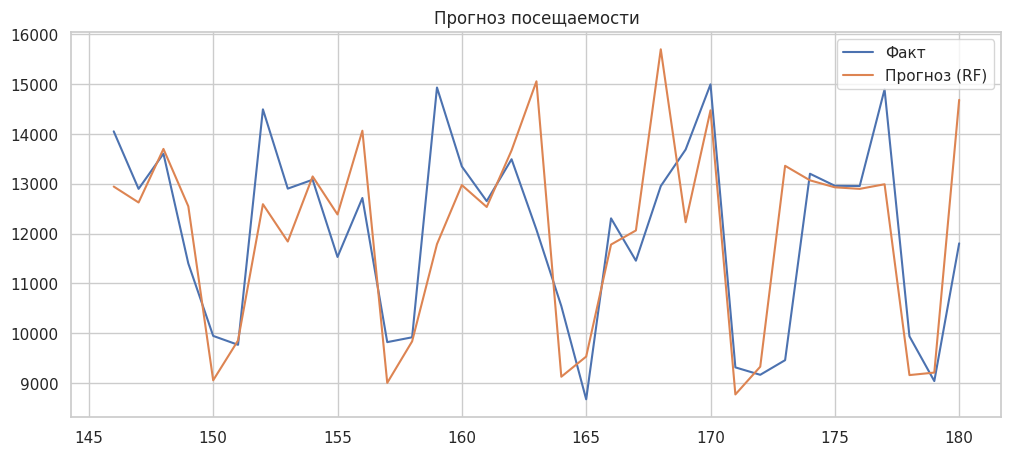

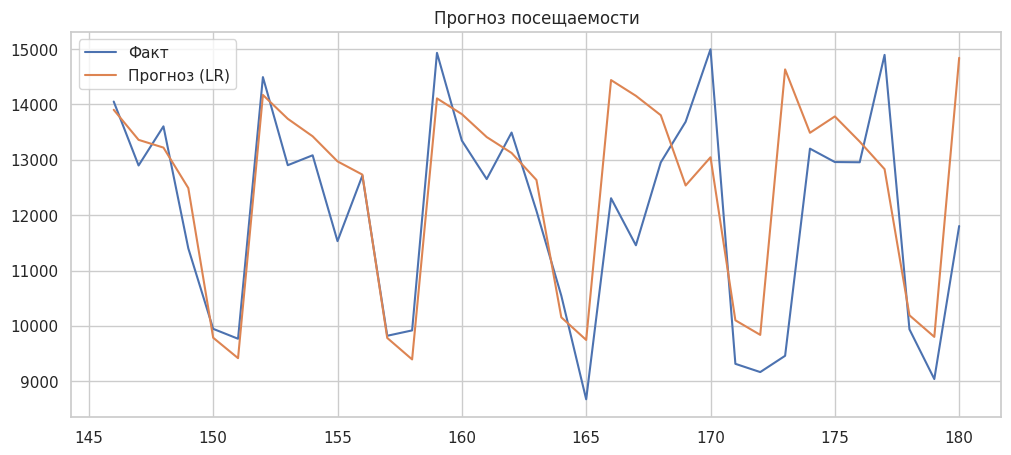

In [35]:
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor


vis = visits_clean.copy()
vis = vis.rename(columns={'дата_события': 'date'})
vis = vis.sort_values('date')

# признаки
vis['day_of_week'] = vis['date'].dt.dayofweek
vis['month'] = vis['date'].dt.month
vis['is_weekend'] = vis['day_of_week'].isin([5, 6]).astype(int)

# лаг
vis['lag_7'] = vis['visits'].shift(7)

vis = vis.dropna()

features = ['day_of_week', 'month', 'is_weekend', 'holiday_flag', 'lag_7']
X = vis[features]
y = vis['visits']

# train/test split по времени (20% в тест)
split = int(len(vis) * 0.8)
X_train, X_test = X.iloc[:split], X.iloc[split:]
y_train, y_test = y.iloc[:split], y.iloc[split:]

# модели
lr = LinearRegression()
rf = RandomForestRegressor(n_estimators=200, random_state=42)

lr.fit(X_train, y_train)
rf.fit(X_train, y_train)

pred_lr = lr.predict(X_test)
pred_rf = rf.predict(X_test)

# метрики
def metrics(true, pred):
    mae = mean_absolute_error(true, pred)
    rmse = np.sqrt(mean_squared_error(true, pred))
    mape = np.mean(np.abs((true - pred) / true)) * 100
    return mae, rmse, mape

lr_mae, lr_rmse, lr_mape = metrics(y_test, pred_lr)
rf_mae, rf_rmse, rf_mape = metrics(y_test, pred_rf)

print("Linear Regression")
print(f"MAE: {lr_mae:.1f}, RMSE: {lr_rmse:.1f}, MAPE: {lr_mape:.2f}%")

print("\nRandom Forest")
print(f"MAE: {rf_mae:.1f}, RMSE: {rf_rmse:.1f}, MAPE: {rf_mape:.2f}%")

# график прогноза для рандом форест
plt.figure(figsize=(12,5))
plt.plot(y_test.index, y_test.values, label='Факт')
plt.plot(y_test.index, pred_rf, label='Прогноз (RF)')
plt.title('Прогноз посещаемости')
plt.legend()
plt.show()

# график прогноза для линейной модели
plt.figure(figsize=(12,5))
plt.plot(y_test.index, y_test.values, label='Факт')
plt.plot(y_test.index, pred_lr, label='Прогноз (LR)')
plt.title('Прогноз посещаемости')
plt.legend()
plt.show()

Для прогноза посещаемости были обучены две модели:

Linear Regression и RandomForestRegressor

Разделение выполнено с учётом временного ряда:
80% данных использованы как обучающая выборка, 20% — как тестовая.

Интерпретация:

MAE показывает, что линейная модель ошибается в среднем на 960 посещений в день.
Для Random Forest ошибка немного выше — около 1007 посещений.

MAPE около 8% означает, что прогноз в среднем отклоняется от реальности на 8% ежедневной посещаемости.

RMSE выше MAE, это говорит о наличии отдельных дней со значительными отклонениями (пики или провалы посещений).

Если сравнить метрики, то получится, что:

Linear Regression имеет меньшую ошибку по всем метрикам.

Следовательно, лучшая модель — Linear Regression.


Прогноз на следующую неделю

Прогноз посещаемости на следующую неделю



,date,predicted_visits
0,2025-11-18,14166.959407
1,2025-11-19,13783.576875
2,2025-11-20,13382.720919
3,2025-11-21,12839.140847
4,2025-11-22,10952.102530
5,2025-11-23,10616.955463
6,2025-11-24,14670.747055


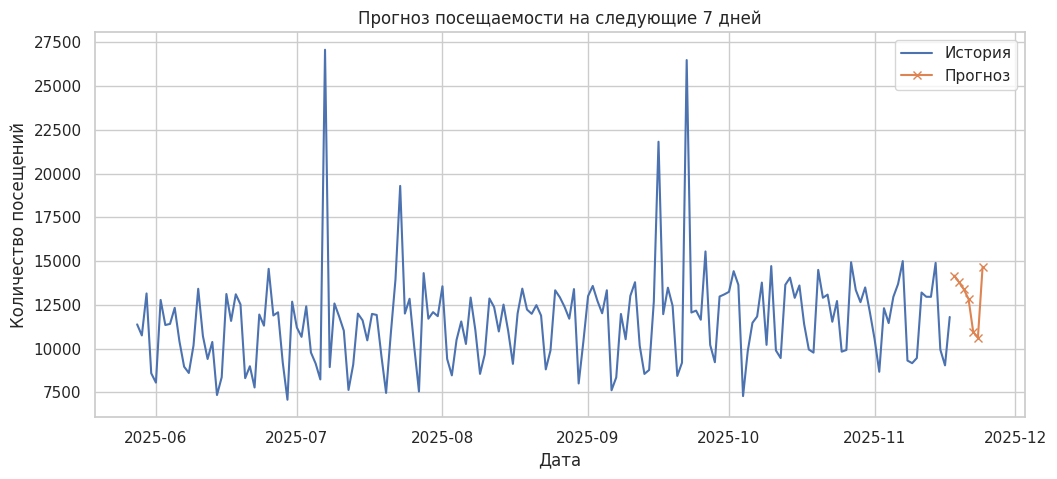

In [34]:
# Испольуем модель Linear Regression
best_model = lr

forecast_df = vis.copy().sort_values("date").reset_index(drop=True)

# берем последнюю дату в данных
last_date = forecast_df["date"].max()

# создадие 7-ми дат вперёд
future_dates = pd.date_range(start=last_date + pd.Timedelta(days=1), periods=7)

# Создаём датафрейм для будущих дат
future = pd.DataFrame({"date": future_dates})

future["day_of_week"] = future["date"].dt.dayofweek
future["month"] = future["date"].dt.month
future["is_weekend"] = future["day_of_week"].isin([5, 6]).astype(int)

future["holiday_flag"] = 0

# создание лагового признака
future["lag_7"] = forecast_df["visits"].iloc[-7:].values

future_X = future[["day_of_week", "month", "is_weekend", "holiday_flag", "lag_7"]]

# прогноз
future["predicted_visits"] = best_model.predict(future_X)

print("Прогноз посещаемости на следующую неделю\n")
display(future[["date", "predicted_visits"]])

# график прогноза
plt.figure(figsize=(12,5))
plt.plot(forecast_df["date"], forecast_df["visits"], label="История")
plt.plot(future["date"], future["predicted_visits"], label="Прогноз", marker="x")
plt.title("Прогноз посещаемости на следующие 7 дней")
plt.xlabel("Дата")
plt.ylabel("Количество посещений")
plt.legend()
plt.grid(True)
plt.show()
